In [1]:
import kagglehub
path = kagglehub.dataset_download("gti-upm/leapgestrecog")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/organizations/gti-upm/leapgestrecog


In [11]:
import os
DATADIR = "/kaggle/input/datasets/organizations/gti-upm/leapgestrecog"
print(os.listdir(DATADIR))

['leapGestRecog', 'leapgestrecog']


In [12]:
import os
path = "/kaggle/input/datasets/organizations/gti-upm/leapgestrecog/leapGestRecog"
print(os.listdir(path))

['07', '05', '06', '02', '04', '00', '08', '09', '03', '01']


✅ Accuracy: 98.83%


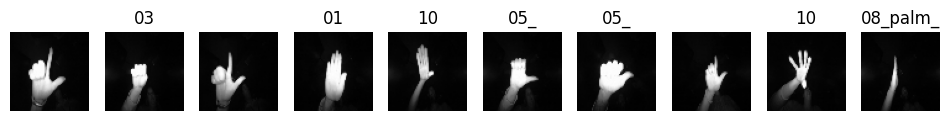

In [15]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
DATADIR = "/kaggle/input/datasets/organizations/gti-upm/leapgestrecog/leapGestRecog"
data = []
categories = []
for person in os.listdir(DATADIR):
    person_path = os.path.join(DATADIR, person)
    for gesture in os.listdir(person_path):
        gesture_path = os.path.join(person_path, gesture)
        if gesture not in categories:
            categories.append(gesture)
        label = categories.index(gesture)
        for img in os.listdir(gesture_path)[:30]:
            try:
                img_path = os.path.join(gesture_path, img)
                image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                image = cv2.resize(image, (64,64))
                data.append([image, label])
            except:
                pass
X = []
y = []

for features, label in data:
    X.append(features)
    y.append(label)

X = np.array(X).reshape(len(X), -1)
y = np.array(y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
model = SVC(kernel='rbf')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {accuracy*100:.2f}%")
plt.figure(figsize=(12,6))
for i in range(10):
    plt.subplot(1,10,i+1)
    img = X_test[i].reshape(64,64)
    plt.imshow(img, cmap='gray')
    plt.title(categories[y_pred[i]][:-5])
    plt.axis("off")
plt.show()